# regressione lineare
**obiettivo**: identificare la retta che approssima bene il comportamento di una funzione obiettivo $f(x)$

La seguente formula, alcola approssimativamente quanto ci vuole per percorrere una distanza di $L$ metri su dislivello $D$ in montagna.
$$
t \approx \frac{L(km)}{5} + \frac{D(m)}{600}
$$

In [ ]:
import pandas as pd
import os
import m1atplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv(os.path.join('dataset', 'trail_running.csv'), sep=';')
df.columns = ['Gara', 'Lunghezza', 'D+', 'Tempo']
df['Lunghezza'] = df['Lunghezza']*1000

In [ ]:
# to_timedelta(str) trasforma la stringa in un oggetto timedelta
df['Tempo'] = pd.to_timedelta(df['Tempo']).dt.total_seconds()/60
df.columns = ['Gara', 'Lunghezza', 'D+', 'Minuti']

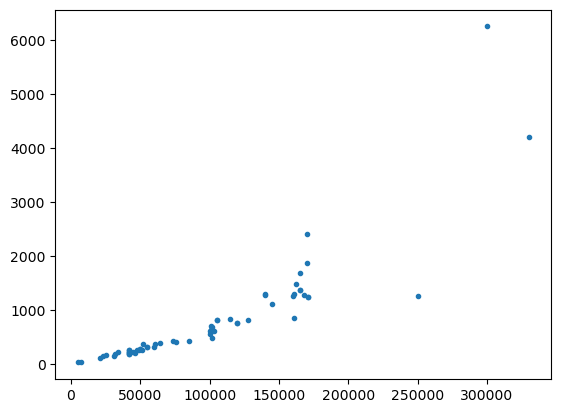

In [4]:
plt.scatter(df['Lunghezza'], df['Minuti'], marker='.')

# filtare
* devo togliere dai dati le maratone troppo lunghe, su queste l'approssimazione non funziona e produce dati sbagliati
* guardando il grafico si nota che i dati sono distribuiti meglio su una retta

In [9]:
# mi prendo gli indici per cui la lunghezza e' < 100000
df = df[df['Lunghezza'] < 100000]
# e' un dizionario di booleani
df['Lunghezza'] < 100000

3     True
6     True
7     True
9     True
13    True
17    True
20    True
21    True
22    True
25    True
26    True
27    True
28    True
30    True
31    True
33    True
37    True
38    True
39    True
40    True
42    True
43    True
44    True
45    True
46    True
47    True
48    True
50    True
57    True
59    True
61    True
Name: Lunghezza, dtype: bool

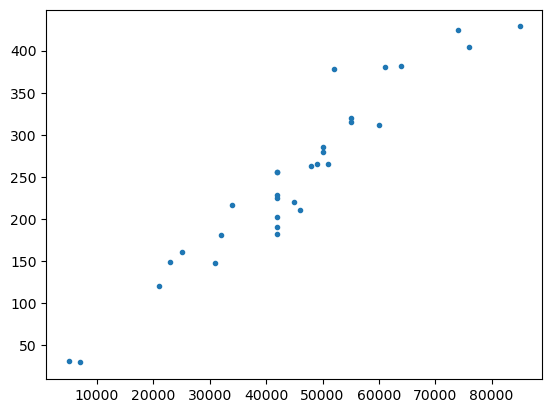

In [10]:
plt.scatter(df['Lunghezza'], df['Minuti'], marker='.')

## Regressione lineare
* predirre il valore di una variabile su valori continui, analizzando le caratteristiche in input.

$$
y = w_0 + \sum_{i=1}^{d} w_i x_i.
$$

* **iperpiano**: il vettore $x = (x_1,\ldots, x_d)$ è definito nello spazio delle caratteristiche e $w=(w_0,\ldots, w_d)$ sono i coefficienti dell'iperpiano. L'iperpiano deve approssimare nel miglior modo possibile i dati osservati

**assumiamo che**:
- $x_0$ sia sempre $1$
- $w = (w_0,\ldots, w_d)$ e $x = (1, x_1,\ldots, x_d)$ 

$$
y = w_0 + \sum_{i=1}^{d} w_i x_i = \sum_{i=0}^{d} w_i x_i = w \cdot x.
$$

- $\cdot$ e' il prodotto scalare.

**ottimizzare**:
* $n$ campioni di addestramento
* $X \in R^{n\times d}$ e' la matrice che codifica le features
* $y \in R^n$ e' l'output della riga di features
* **voglio trovare**: $w^*$ che minimizza l'errore $J(w)$

$$
J(w) = \frac{1}{2}\sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)^2
$$
* $x^{(i)}$ e $y^{(i)}$ indicano l'i-esimo vettore (o **riga**) nella matrice
* **la costante**: $\frac{1}{2}$ fa comodo quando derivo l'errore.

## minimizzare l'errore
due modi per trovare $w^*$:
* **formula chiusa**: $(X^T X)^{-1} X^T y$ ha costo computazionale elevato. $O(n^3)$
* **discesa del gradiente**: consiste nel calcolare le derivate parziali. ottengo il vettore che descrivere la direzione in cui la funzione sale e va a valle. ottenuto questo vettore, io voglio andare dalla parte opposta.



$$
w \leftarrow w + \Delta w = w -\eta \nabla J(w)
$$

* **gradiente** di $J$: e' il vettore delle derivate parziali.
* **tasso di apprendimento** $\eta$: controlla di quanto ci si sposta in funzione del gradiente. velocizza o rallenta la convergenza dell'algoritmo.
* * **converge se**: la funzione ha un solo minimo ed e' derivabile. se ha piu minimi locali, l'algoritmo si inceppa.
* * **nel nostro caso**: la funzione e' convessa, dunque l'algoritmo converge sempre.
* * **non deve essere**: ne troppo piccolo (troppo lento e non mi muovo per niente) e ne troppo grande (potrei saltare il minimo e non convergere mai)
* **da dove comincio**? scelgo un punto a caso.



$$
\frac{\partial J}{\partial w_j} = \frac{\partial}{\partial w_j} \frac{1}{2}\sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)^2
$$

$$
= \frac{1}{2}\sum_{i=1}^n 2  \left( y^{(i)} - w\cdot x^{(i)} \right)\frac{\partial}{\partial w_j}\left( y^{(i)} - w\cdot x^{(i)} \right)
$$

$$
 = \sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)\frac{\partial}{\partial w_j}\left( y^{(i)} - \sum_{k=1}^{d}w_k\cdot x^{(i)}_k \right)
$$

$$
= \sum_{i=1}^n \left( y^{(i)} - w\cdot x^{(i)} \right)(-x^{(i)}_j)
$$

$$
=-\sum_{i=1}^n x^{(i)}_j \left( y^{(i)} - w\cdot x^{(i)} \right)
$$

<!----$$
= - x_j\cdot(y-w\cdot x^{(i)})
$$-->

All'ultimo passaggio, quando derivo $\left( y^{(i)} - \sum_{k=1}^{d}w_k\cdot x^{(i)}_k \right)$ sopravvive solo il termine $x_j$. quando derivo $w_k \neq w_j$, questo diventa 0, dunque sopravvive solo $x_j$ che viene moltiplicata per la derivata di $w_j$ che e' 1.

Dove $x_j$ rappresenta la colonna $j$ di $X$ e $x^{(i)}$ indica la riga $i$.  Quindi, la precedente può essere riscritta come al prodotto scalare del vettore colonna $j$ di $X$ per il vettore

$$
\texttt{errors} = \left(
\begin{array}{c}
y^{(1)}-w\cdot x^{(1)}\\
\vdots\\
y^{(n)}-w\cdot x^{(n)}
\end{array}
\right)
$$

quindi

$$
\nabla J(w) = - X^T\times \texttt{errors}
$$
* trasposta perche' la riga mi deve diventare una colonna


Dove il precedente è un prodotto matrice-vettore.

```python
'''
Parametri: X, matrice di addestramento; y, vettore etichette; eta, tasso di apprendimento;
'''
        for _ in range(max_num_iterations):
            # calcola l'errore rispetto alla y
            errors = (y -  np.dot(X, w[1:]) + w[0] )
            # fai il prodotto matriciale con la trasposta
            w[1:] += eta * X.T.dot(errors)
            # ho una colonna di uno da moltiplicare con il coefficiente
            w[0]  += eta * errors.sum()
            # errore al quadrato diviso 2!
            cost = (errors**2).sum() / 2.0
            costs.append(cost)
```